In [520]:
import torch
from torch import nn

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from torch.utils.data import random_split

from tqdm import tqdm

torch.manual_seed(128)

In [521]:
## Dataset
N = 100
w = 2.5

## Model
lr = 0.01

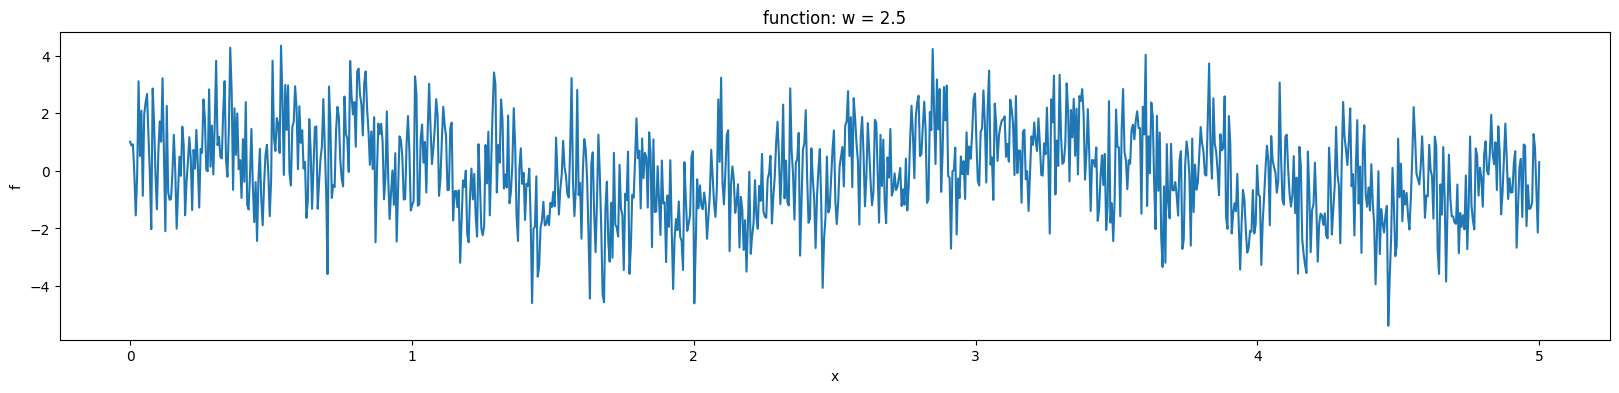

In [522]:
def fn(w, x, noise: bool = False):
    if noise: return torch.sin(100 * w * x) + torch.sin(10 * w * x) + torch.sin(w * x) + torch.randn(x.shape)
    else: return torch.sin(100 * w * x) + torch.sin(10 * w * x) + torch.sin(w * x)

x = torch.linspace(0, 5, 1000)
data = fn(w, x, noise = True)
plt.figure(figsize=(20,4))
plt.plot(x, data)
plt.xlabel("x")
plt.ylabel("f")

plt.title(f"function: w = {w}")

plt.show()


In [523]:
class x_y_ds(Dataset):
    def __init__(self, fn, N):

        self.xs = torch.linspace(0, 5, N).unsqueeze(1)
        self.ys = fn(w, self.xs, noise = True)

    def __len__(self):
        return len(self.ys)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys[idx]
    
data = x_y_ds(fn, N = 2000)

In [524]:
train_size = int(0.8 * len(data))
test_size = len(data) - train_size

training_dataset, test_dataset = random_split(
    data, [train_size, test_size]
)

train_dataloader = DataLoader(dataset = training_dataset, batch_size=10, shuffle=True)
test_dataloader = DataLoader(dataset = test_dataset, batch_size=10, shuffle=False)

In [592]:
class Model(torch.nn.Module):
    def __init__(self, width, depth, act = "sigmoid", skip = 0):
        super().__init__()

        self.skip = skip
        self.input_l = torch.nn.Linear(1, width)
        self.hidden_l = torch.nn.ModuleList([torch.nn.Linear(width, width) for i in range(depth)])
        self.output_l = torch.nn.Linear(width, 1)
        if act == "sigmoid": self.act = torch.nn.Sigmoid()
        elif act == "tanh": self.act = torch.nn.Tanh()
        elif act == "relu": self.act = torch.nn.ReLU()
    
    def forward(self, x):
        a = self.act(self.input_l(x))

        if self.skip > 0:
            for idx, linear in enumerate(self.hidden_l):
                z = self.act(linear(a))
                if idx % self.skip == 0:
                    a = a + z
                else:
                    a = z
        else:
            for linear in self.hidden_l:
                a = self.act(linear(a))

        return self.output_l(a)

model = Model(width = 10, depth = 10)
model

Model(
  (input_l): Linear(in_features=1, out_features=10, bias=True)
  (hidden_l): ModuleList(
    (0-9): 10 x Linear(in_features=10, out_features=10, bias=True)
  )
  (output_l): Linear(in_features=10, out_features=1, bias=True)
  (act): Sigmoid()
)

In [526]:
def train_model(model, train_dataloader, test_dataloader, optimizer, loss_fn, epochs=100, l1_lambda = 0, l2_lambda = 0, plot = True, plot_title = ""):

    logs = {
        "train_loss": [],
        "test_loss": []
    }

    for epoch in tqdm(range(epochs)):
        # Testing
        model.eval()
        test_loss = 0

        with torch.no_grad():
            for x_batch, y_batch in test_dataloader:

                y_pred = model(x_batch)
                loss = loss_fn(y_pred, y_batch)

                test_loss += loss.item()

        test_loss /= len(test_dataloader)
        logs["test_loss"].append(test_loss)


        # Training 
        model.train()
        train_loss = 0

        for x_batch, y_batch in train_dataloader:

            optimizer.zero_grad()

            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)

            # L1 penalty
            if l1_lambda > 0:
                l1_penalty = sum(p.abs().sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_penalty

            # L2 penalty
            if l2_lambda > 0:
                l2_penalty = sum(p.pow(2).sum() for p in model.parameters())
                loss = loss + l2_lambda * l2_penalty

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_dataloader)
        logs["train_loss"].append(train_loss)


       

    if plot:
        plt.plot(logs["train_loss"], label = "Train Loss")
        plt.plot(logs["test_loss"], label = "Test Loss")

        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.legend()

        plt.title(plot_title)  


    return logs

# Q1

100%|██████████| 50/50 [00:03<00:00, 13.47it/s]


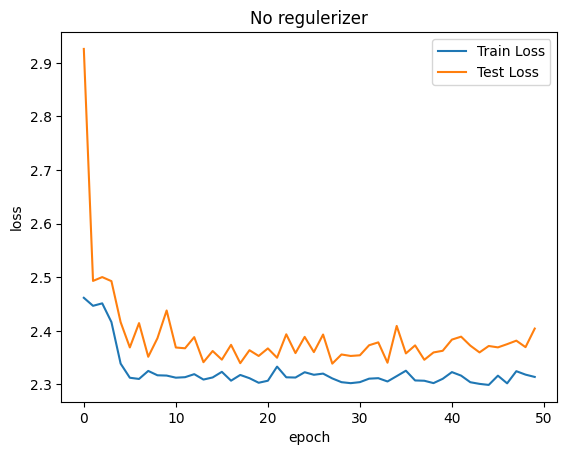

In [527]:
loss_fn = torch.nn.MSELoss()
no_reg_model = Model(width = 10, depth = 5)
adam = torch.optim.Adam(no_reg_model.parameters(), lr=lr)

no_reg_logs = train_model(
    no_reg_model,
    train_dataloader,
    test_dataloader,
    adam,
    loss_fn,
    epochs=50, 
    plot = True,
    plot_title = "No regulerizer"
)

100%|██████████| 50/50 [00:05<00:00,  9.63it/s]


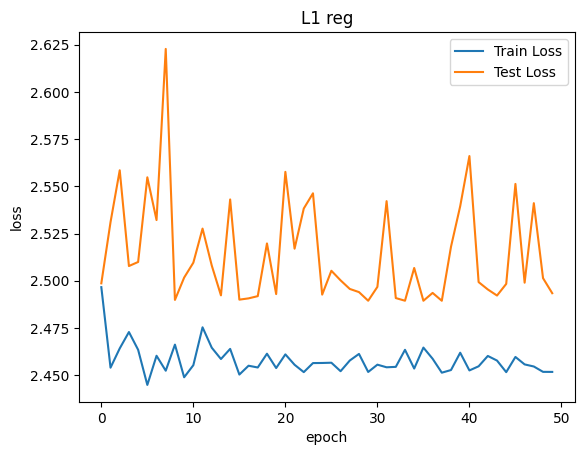

In [528]:
loss_fn = torch.nn.MSELoss()
l1_model = Model(width = 10, depth = 5)
adam = torch.optim.Adam(l1_model.parameters(), lr=lr)

l1_logs = train_model(
    l1_model,
    train_dataloader,
    test_dataloader,
    adam,
    loss_fn,
    epochs=50, 
    plot = True,
    plot_title = "L1 reg", 
    l1_lambda = 1e-3
)

100%|██████████| 50/50 [00:05<00:00,  9.06it/s]


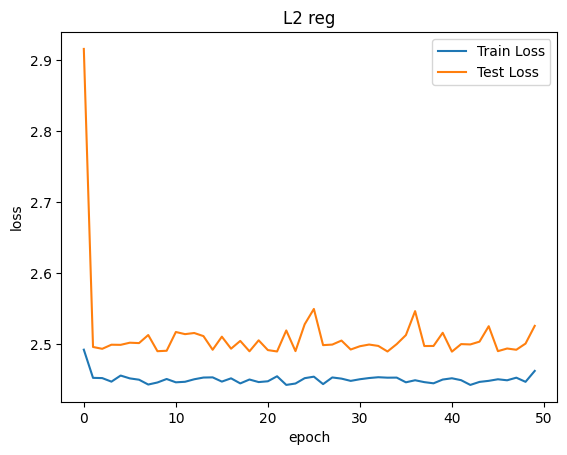

In [529]:
loss_fn = torch.nn.MSELoss()
l2_model = Model(width = 10, depth = 5)
adam = torch.optim.Adam(l2_model.parameters(), lr=lr)

l2_logs = train_model(
    l2_model,
    train_dataloader,
    test_dataloader,
    adam,
    loss_fn,
    epochs=50, 
    plot = True,
    plot_title = "L2 reg", 
    l2_lambda = 1e-3
)

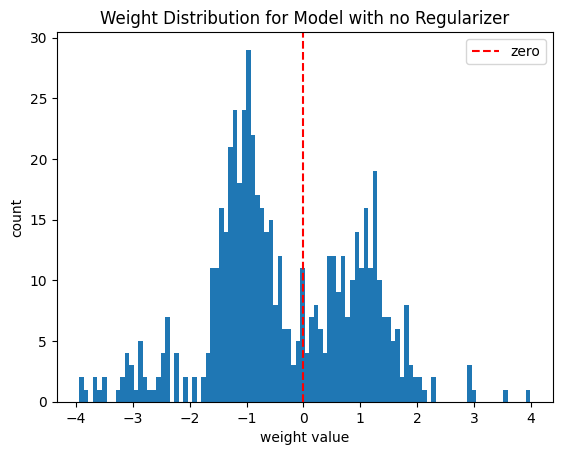

In [530]:
all_weights = torch.cat([p.data.flatten() for p in no_reg_model.parameters()])

plt.hist(all_weights.numpy(), bins=100)
plt.axvline(x=0, color='red', linestyle='--', label='zero')
plt.xlabel("weight value")
plt.ylabel("count")
plt.title("Weight Distribution for Model with no Regularizer")
plt.legend()
plt.show()

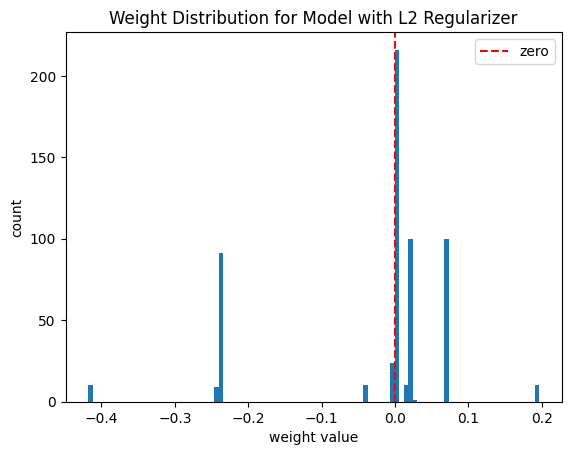

In [531]:
all_weights = torch.cat([p.data.flatten() for p in l2_model.parameters()])

plt.hist(all_weights.numpy(), bins=100)
plt.axvline(x=0, color='red', linestyle='--', label='zero')
plt.xlabel("weight value")
plt.ylabel("count")
plt.title("Weight Distribution for Model with L2 Regularizer")
plt.legend()
plt.show()

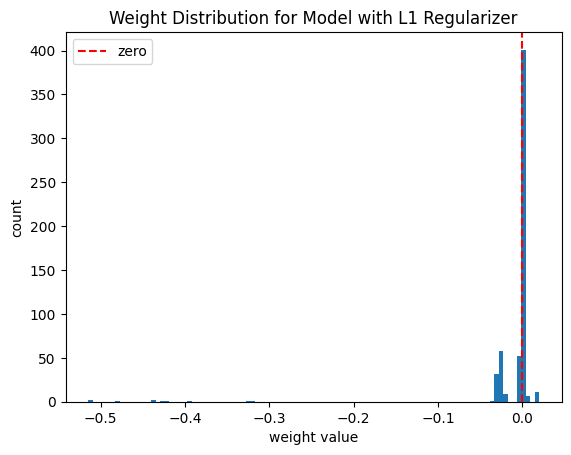

In [532]:
all_weights = torch.cat([p.data.flatten() for p in l1_model.parameters()])

plt.hist(all_weights.numpy(), bins=100)
plt.axvline(x=0, color='red', linestyle='--', label='zero')
plt.xlabel("weight value")
plt.ylabel("count")
plt.title("Weight Distribution for Model with L1 Regularizer")
plt.legend()
plt.show()

# Q2

In [533]:
x_l = []
y_l = []
for x, y in data:
    x_l.append(x.item())
    y_l.append(y.item())




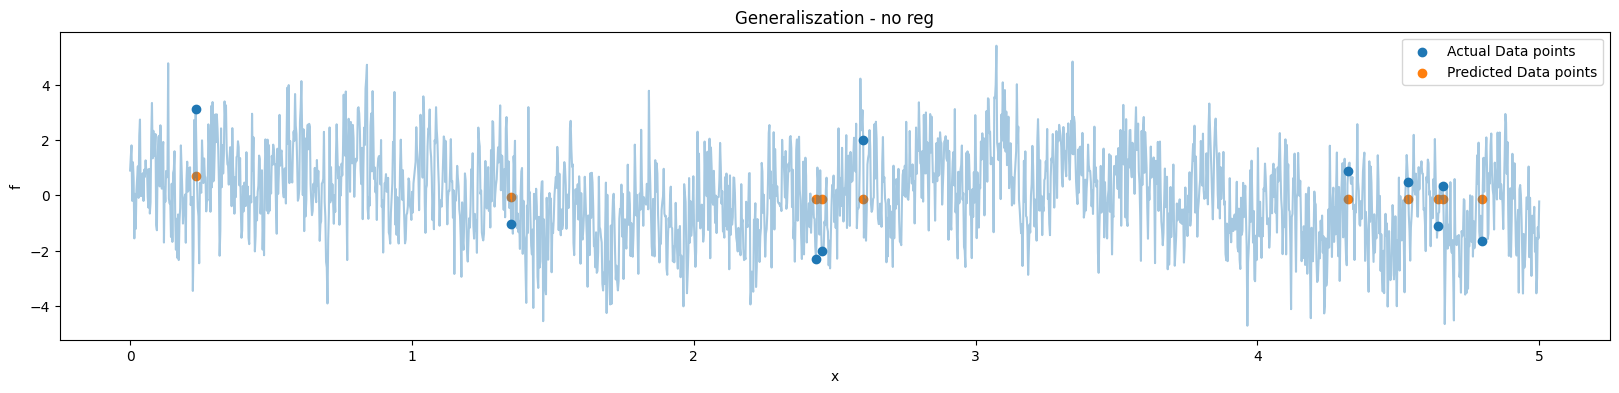

In [534]:
plt.figure(figsize=(20,4))
plt.plot(x_l, y_l, alpha = 0.4)
plt.xlabel("x")
plt.ylabel("f")

x_gen, y_gen = next(iter(test_dataloader))
y_pred = no_reg_model(x_gen)

plt.scatter(x_gen, y_gen, alpha = 1, label = "Actual Data points")
plt.scatter(x_gen, y_pred.detach().numpy(), alpha = 1, label = "Predicted Data points")

plt.legend()
plt.title(f"Generaliszation - no reg")
plt.show()

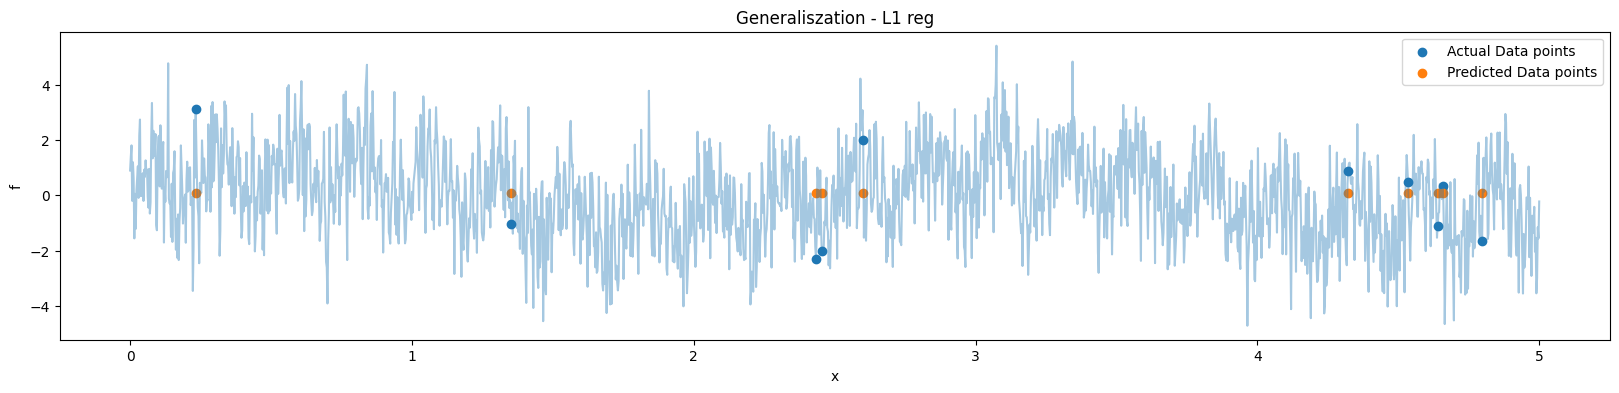

In [535]:
plt.figure(figsize=(20,4))
plt.plot(x_l, y_l, alpha = 0.4)
plt.xlabel("x")
plt.ylabel("f")

x_gen, y_gen = next(iter(test_dataloader))
y_pred = l1_model(x_gen)

plt.scatter(x_gen, y_gen, alpha = 1, label = "Actual Data points")
plt.scatter(x_gen, y_pred.detach().numpy(), alpha = 1, label = "Predicted Data points")

plt.legend()
plt.title(f"Generaliszation - L1 reg")
plt.show()

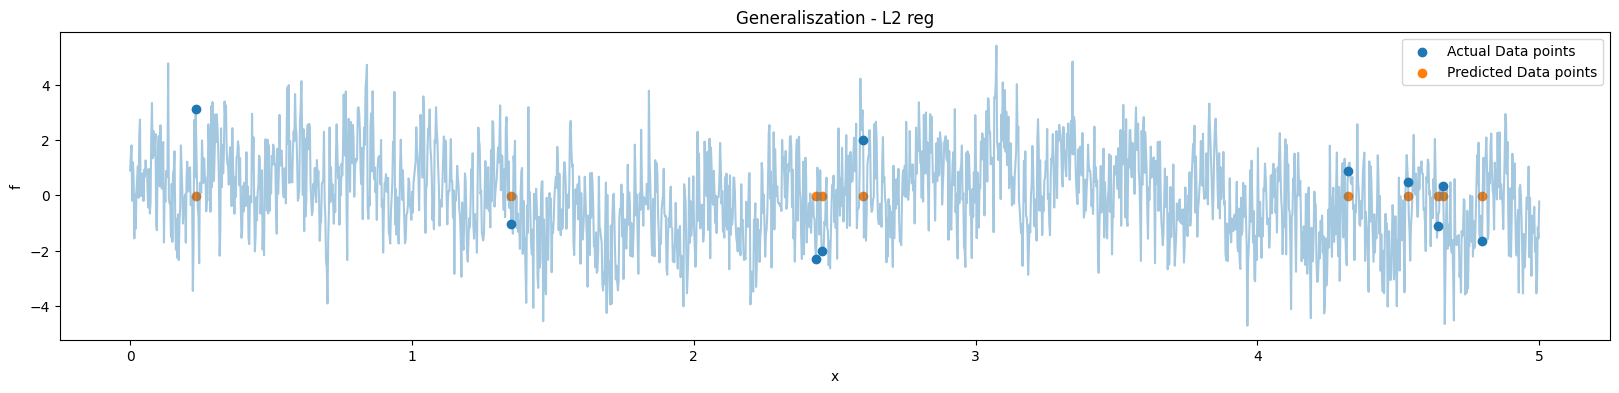

In [536]:
plt.figure(figsize=(20,4))
plt.plot(x_l, y_l, alpha = 0.4)
plt.xlabel("x")
plt.ylabel("f")

x_gen, y_gen = next(iter(test_dataloader))
y_pred = l2_model(x_gen)

plt.scatter(x_gen, y_gen, alpha = 1, label = "Actual Data points")
plt.scatter(x_gen, y_pred.detach().numpy(), alpha = 1, label = "Predicted Data points")

plt.legend()
plt.title(f"Generaliszation - L2 reg")
plt.show()

100%|██████████| 50/50 [00:05<00:00,  9.11it/s]


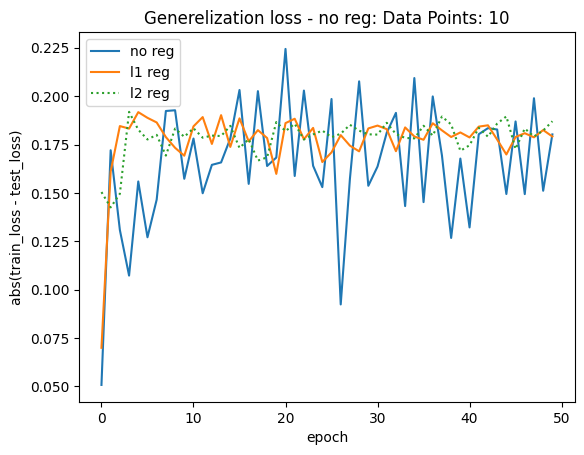

100%|██████████| 50/50 [00:05<00:00,  8.63it/s]


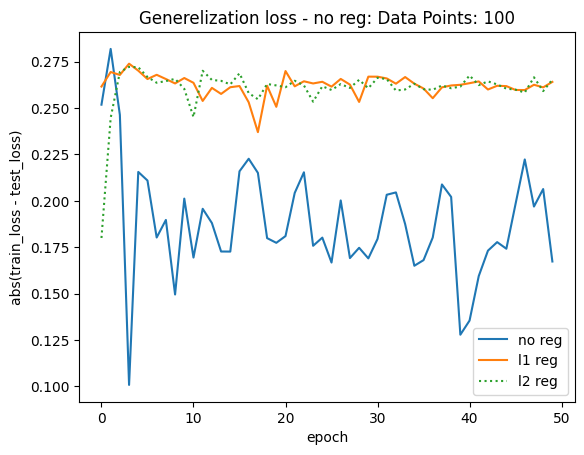

100%|██████████| 50/50 [00:05<00:00,  9.25it/s]


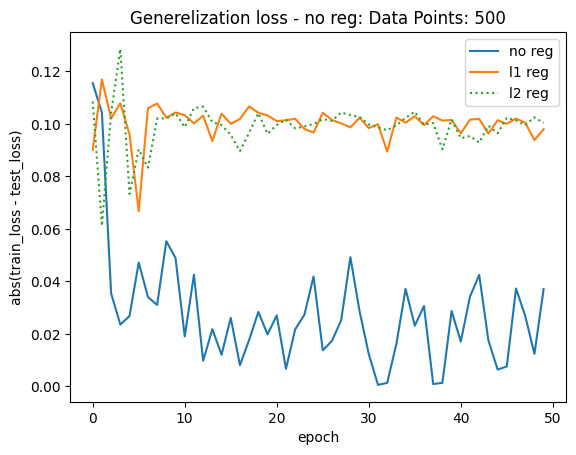

100%|██████████| 50/50 [00:05<00:00,  9.24it/s]


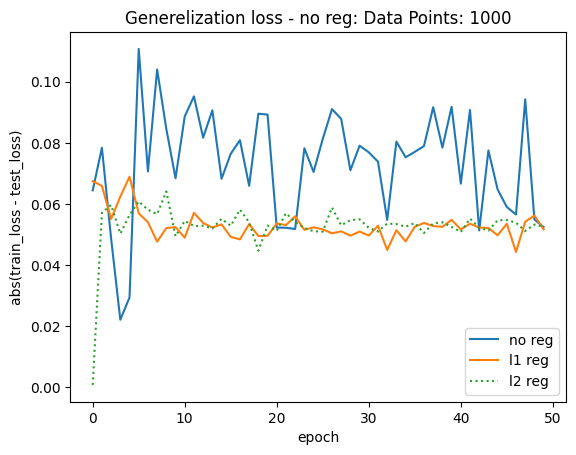

100%|██████████| 50/50 [00:05<00:00,  9.12it/s]


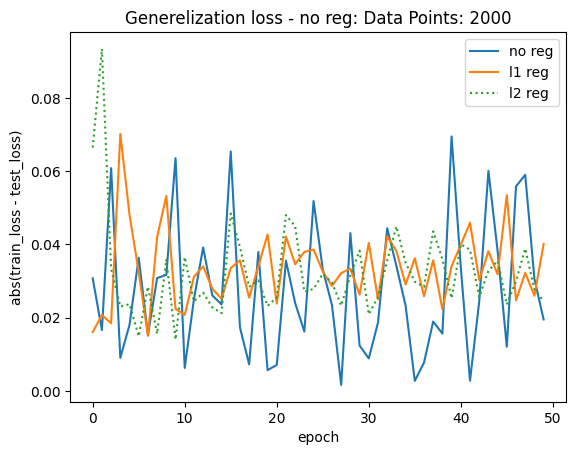

100%|██████████| 50/50 [00:05<00:00,  9.05it/s]


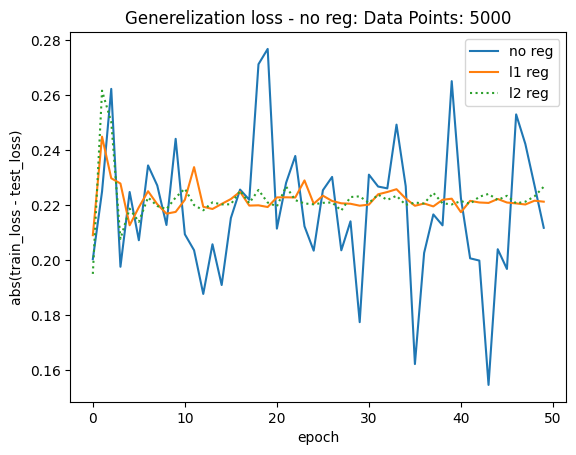

100%|██████████| 50/50 [00:05<00:00,  9.04it/s]


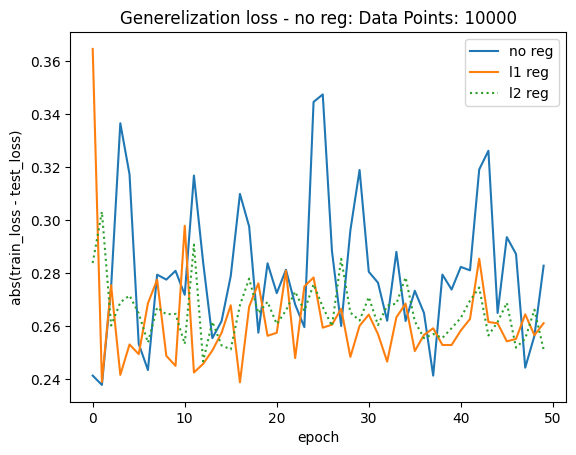

In [547]:
data_size = [10, 100, 500, 1000, 2000, 5000, 10_000]
for d in data_size:
    data = x_y_ds(fn, N = 2000)
    train_size = int(0.8 * len(data))
    test_size = len(data) - train_size

    training_dataset, test_dataset = random_split(
        data, [train_size, test_size]
    )

    train_dataloader = DataLoader(dataset = training_dataset, batch_size=10, shuffle=True)
    test_dataloader = DataLoader(dataset = test_dataset, batch_size=10, shuffle=False)

    loss_fn = torch.nn.MSELoss()
    no_reg_model = Model(width = 10, depth = 5)
    adam = torch.optim.Adam(no_reg_model.parameters(), lr=lr)

    no_reg_logs = train_model(
        no_reg_model,
        train_dataloader,
        test_dataloader,
        adam,
        loss_fn,
        epochs=50, 
        plot = False,
        plot_title = "No regulerizer"
    )

    loss_fn = torch.nn.MSELoss()
    l1_model = Model(width = 10, depth = 5)
    adam = torch.optim.Adam(l1_model.parameters(), lr=lr)

    l1_logs = train_model(
        l1_model,
        train_dataloader,
        test_dataloader,
        adam,
        loss_fn,
        epochs=50, 
        plot = False,
        plot_title = "L1 reg", 
        l1_lambda = 1e-5
    )


    loss_fn = torch.nn.MSELoss()
    l2_model = Model(width = 10, depth = 5)
    adam = torch.optim.Adam(l2_model.parameters(), lr=lr)

    l2_logs = train_model(
        l2_model,
        train_dataloader,
        test_dataloader,
        adam,
        loss_fn,
        epochs=50, 
        plot = False,
        plot_title = "L2 reg", 
        l2_lambda = 1e-5
    )


    no_reg_gen = abs(np.array(no_reg_logs['train_loss']) - np.array(no_reg_logs['test_loss']))
    l1_gen = abs(np.array(l1_logs['train_loss']) - np.array(l1_logs['test_loss']))
    l2_gen = abs(np.array(l2_logs['train_loss']) - np.array(l2_logs['test_loss']))

    plt.plot(no_reg_gen, label = "no reg")
    plt.plot(l1_gen, label = "l1 reg")
    plt.plot(l2_gen, label = "l2 reg", linestyle=":")

    plt.title(f"Generelization loss - no reg: Data Points: {d}")
    plt.xlabel("epoch")
    plt.ylabel("abs(train_loss - test_loss)")

    plt.legend()
    plt.show()

# Q3

In [ ]:
x_gen, y_gen = next(iter(test_dataloader))
y_pred = no_reg_model(x_gen)

plt.scatter(x_gen, y_gen, alpha = 1, label = "Actual Data points")
plt.scatter(x_gen, y_pred.detach().numpy(), alpha = 1, label = "Predicted Data points")

In [ ]:
torch.tensor(x_l).unsqueeze(-1)

torch.Size([2000, 1])

100%|██████████| 2000/2000 [00:40<00:00, 49.56it/s]


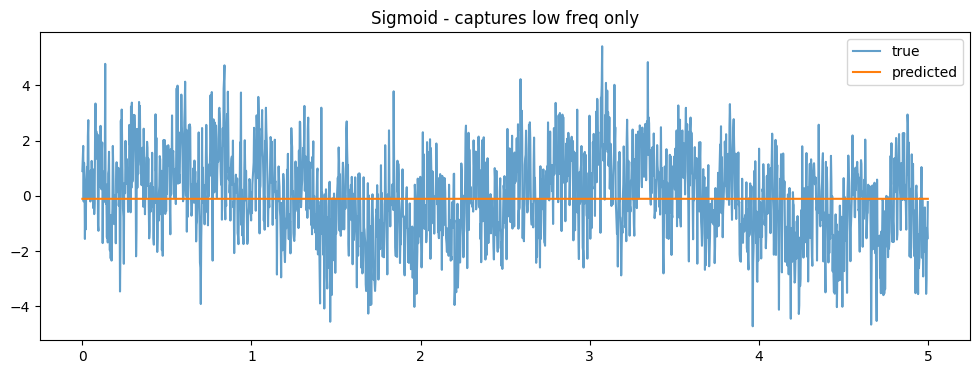

100%|██████████| 2000/2000 [00:42<00:00, 47.15it/s]


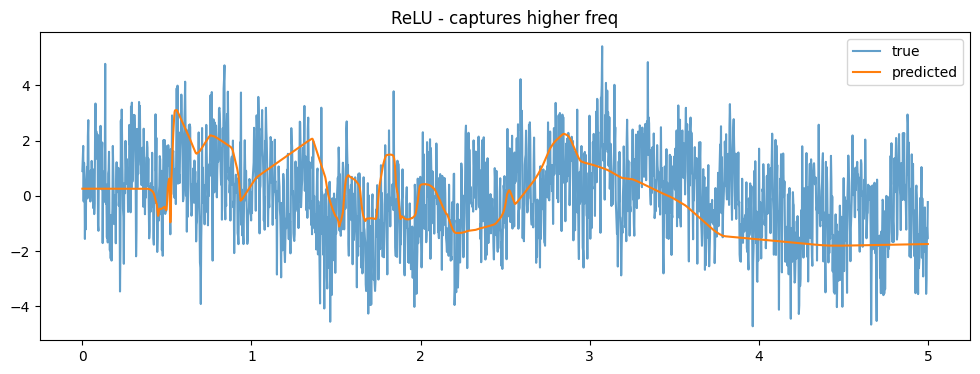

In [609]:
def plot_prediction(model, title):
    model.eval()
    # x = torch.linspace(0, 5, 1000).unsqueeze(1)
    with torch.no_grad():
        y_pred = model(torch.tensor(x_l).unsqueeze(-1))
    # y_true = fn(w, x, noise)
    
    plt.figure(figsize=(12, 4))
    plt.plot(x_l, y_l, label="true", alpha=0.7)
    plt.plot(x_l, y_pred, label="predicted", alpha=1.)
    plt.title(title)
    plt.legend()
    plt.show()


data = x_y_ds(fn, N = 100)
train_size = int(0.8 * len(data))
test_size = len(data) - train_size

training_dataset, test_dataset = random_split(
    data, [train_size, test_size]
)

train_dataloader = DataLoader(dataset = training_dataset, batch_size=10, shuffle=True)
test_dataloader = DataLoader(dataset = test_dataset, batch_size=10, shuffle=False)

# Sigmoid model
sigmoid_model = Model(width=256, depth=10, act="sigmoid")
adam = torch.optim.Adam(sigmoid_model.parameters(), lr=1e-3)
sigmoid_logs = train_model(
        sigmoid_model,
        train_dataloader,
        test_dataloader,
        adam,
        loss_fn,
        epochs=2000, 
        plot = False,
        # l2_lambda = 1e-5
    )
plot_prediction(sigmoid_model, "Sigmoid - captures low freq only")

# ReLU model  
relu_model = Model(width=256, depth=10, act="relu")
adam = torch.optim.Adam(relu_model.parameters(), lr=1e-3)
relu_logs = train_model(
        relu_model,
        train_dataloader,
        test_dataloader,
        adam,
        loss_fn,
        epochs=2000, 
        plot = False,
        # l2_lambda = 1e-5
    )

plot_prediction(relu_model, "ReLU - captures higher freq")

# Q4

In [610]:
def get_gradient_norms(model):
    grad_norms = {}
    # Input layer
    if model.input_l.weight.grad is not None:
        grad_norms['input'] = model.input_l.weight.grad.norm().item()
    # Hidden layers
    for i, layer in enumerate(model.hidden_l):
        if layer.weight.grad is not None:
            grad_norms[f'hidden_{i}'] = layer.weight.grad.norm().item()
    return grad_norms

def train_with_grad_tracking(model, train_dataloader, optimizer, loss_fn, epochs=100):
    grad_history = []  # list of dicts, one per epoch
    
    for epoch in range(epochs):
        model.train()
        for x_batch, y_batch in train_dataloader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            
            grad_history.append(get_gradient_norms(model))
            optimizer.step()
    
    return grad_history

def plot_grad_norms(grad_history, title):
    # Average across all steps
    keys = grad_history[0].keys()
    avg_norms = {k: np.mean([g[k] for g in grad_history]) for k in keys}
    
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(avg_norms)), list(avg_norms.values()))
    plt.xticks(range(len(avg_norms)), list(avg_norms.keys()), rotation=45)
    plt.ylabel("gradient norm")
    plt.title(title)
    plt.yscale("log")  # log scale — vanishing gradients span many orders of magnitude
    plt.tight_layout()
    plt.show()

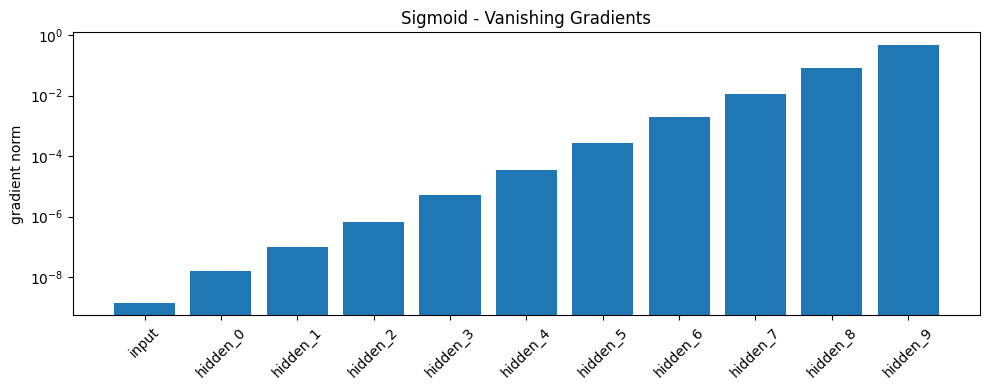

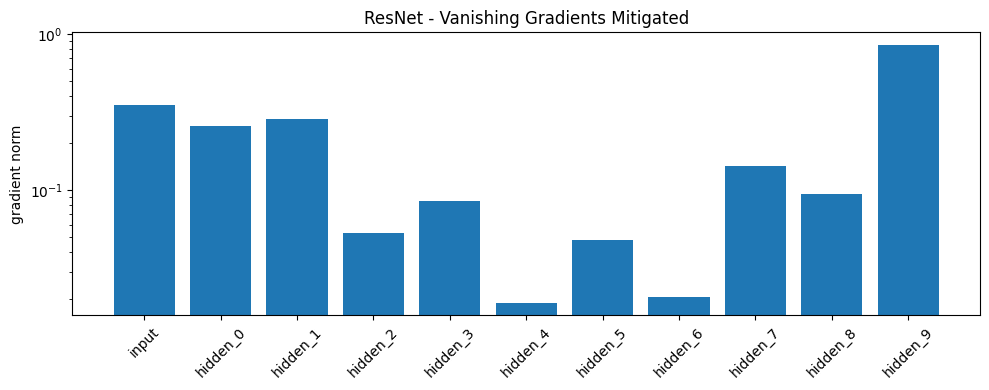

In [611]:
# Deep model — sigmoid, no skip
deep_sigmoid = Model(width=64, depth=10, act="sigmoid", skip=0)
adam = torch.optim.Adam(deep_sigmoid.parameters(), lr=1e-3)
grad_history_sigmoid = train_with_grad_tracking(deep_sigmoid, train_dataloader, adam, loss_fn, epochs=50)
plot_grad_norms(grad_history_sigmoid, "Sigmoid - Vanishing Gradients")

# ResNet — sigmoid with skip connections
resnet_sigmoid = Model(width=64, depth=10, act="sigmoid", skip=2)
adam = torch.optim.Adam(resnet_sigmoid.parameters(), lr=1e-3)
grad_history_resnet = train_with_grad_tracking(resnet_sigmoid, train_dataloader, adam, loss_fn, epochs=50)
plot_grad_norms(grad_history_resnet, "ResNet - Vanishing Gradients Mitigated")

# Q5

In [612]:
# Train deep ReLU (no skip)
deep_relu = Model(width=256, depth=10, act="relu", skip=0)
adam = torch.optim.Adam(deep_relu.parameters(), lr=1e-3)
deep_logs = train_model(deep_relu, train_dataloader, test_dataloader, adam, loss_fn, epochs=2000, plot=False)

# Train ResNet ReLU (skip=2)
resnet_relu = Model(width=256, depth=10, act="relu", skip=2)
adam = torch.optim.Adam(resnet_relu.parameters(), lr=1e-3)
resnet_logs = train_model(resnet_relu, train_dataloader, test_dataloader, adam, loss_fn, epochs=2000, plot=False)

100%|██████████| 2000/2000 [00:42<00:00, 47.38it/s]


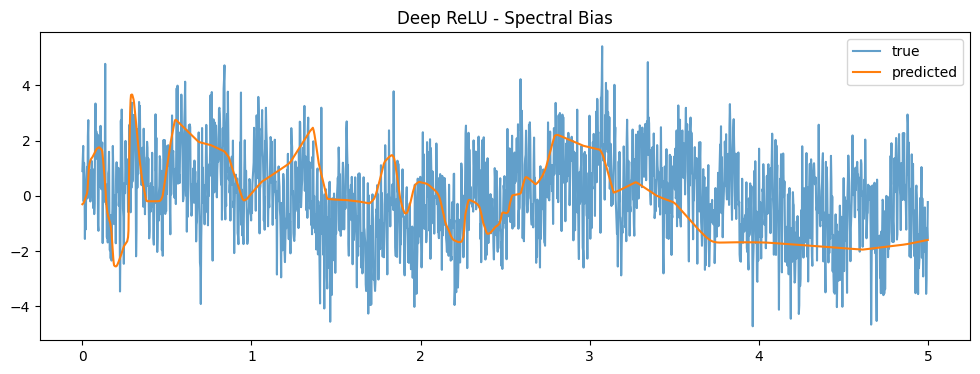

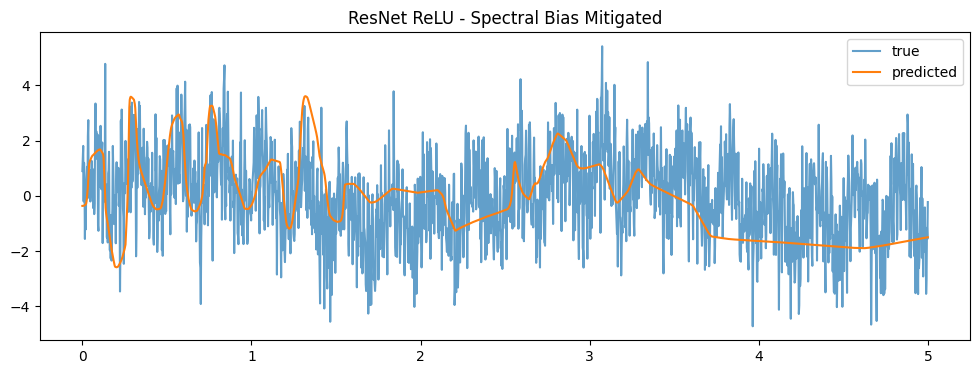

In [613]:
plot_prediction(deep_relu, "Deep ReLU - Spectral Bias")
plot_prediction(resnet_relu, "ResNet ReLU - Spectral Bias Mitigated")